# Garmin Race Prediction Analysis

### How did Garmin's race predictions evolve as my training became more serious?

### How did Garmin's race predictions evolve over time?

### When did predictions become stable?

### Did marathon predictions overshoot actual fitness?

### How did predictions react to: mileage spikes, marathon blocks, races, breaks?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
# Looad parquet file into a pandas DataFrame
daily_master_table = pd.read_parquet('/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/daily_master_v1.parquet')

# Print the shape of the daily master table
print(f'Shape of daily master table {daily_master_table.shape}')

Shape of daily master table (753, 49)


In [3]:
# Print the information of the daily master table
print(daily_master_table.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 49 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            753 non-null    datetime64[ns]
 1   run_count                       753 non-null    int64         
 2   total_distance_km               753 non-null    float64       
 3   total_distance_miles            753 non-null    float64       
 4   total_duration_minutes          753 non-null    float64       
 5   total_moving_minutes            753 non-null    float64       
 6   total_elevation_gain_m          753 non-null    float64       
 7   avg_hr                          738 non-null    float64       
 8   max_hr                          738 non-null    float64       
 9   avg_pace_mile                   753 non-null    float64       
 10  avg_power                       422 non-null    float64       
 11  max_po

In [4]:
# Print a description of the daily master table
print(daily_master_table.describe())

                                date   run_count  total_distance_km  \
count                            753  753.000000         753.000000   
mean   2024-07-19 20:06:41.593625344    1.373174          11.839911   
min              2016-11-13 00:00:00    1.000000           0.764540   
25%              2023-10-20 00:00:00    1.000000           6.896880   
50%              2024-10-05 00:00:00    1.000000          10.383250   
75%              2025-08-01 00:00:00    1.000000          16.113580   
max              2026-05-07 00:00:00    4.000000          42.550762   
std                              NaN    0.720278           7.038865   

       total_distance_miles  total_duration_minutes  total_moving_minutes  \
count            753.000000              753.000000            753.000000   
mean               7.356980               57.428514             56.309651   
min                0.475063                3.555600              0.000000   
25%                4.285522               35.638083 

In [5]:
# Need to convert prediction times to seconds in order to be used in analysis
predictions_type = ['5K_pred', '10K_pred', 'Half_pred', 'Marathon_pred']

for prediction in predictions_type:
    print("Current data type: ")
    print(type(prediction))
    print("Converting to minutes...")
    daily_master_table[prediction] = pd.to_timedelta(daily_master_table[prediction]) # minutes
    print('Conversion sucesful!')
    print(type(daily_master_table[prediction]))

    daily_master_table[prediction] = (
    pd.to_timedelta(daily_master_table[prediction])
    .dt.total_seconds() / 60
)

print(daily_master_table.info())

Current data type: 
<class 'str'>
Converting to minutes...
Conversion sucesful!
<class 'pandas.core.series.Series'>
Current data type: 
<class 'str'>
Converting to minutes...
Conversion sucesful!
<class 'pandas.core.series.Series'>
Current data type: 
<class 'str'>
Converting to minutes...
Conversion sucesful!
<class 'pandas.core.series.Series'>
Current data type: 
<class 'str'>
Converting to minutes...
Conversion sucesful!
<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 49 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            753 non-null    datetime64[ns]
 1   run_count                       753 non-null    int64         
 2   total_distance_km               753 non-null    float64       
 3   total_distance_miles            753 non-null    float64       
 4   total_duration_min

In [6]:
# Print a random sample from the table to verify that everything looks correct
print(daily_master_table.sample(3)['5K_pred'])

655    16.933333
405    16.333333
209          NaN
Name: 5K_pred, dtype: float64


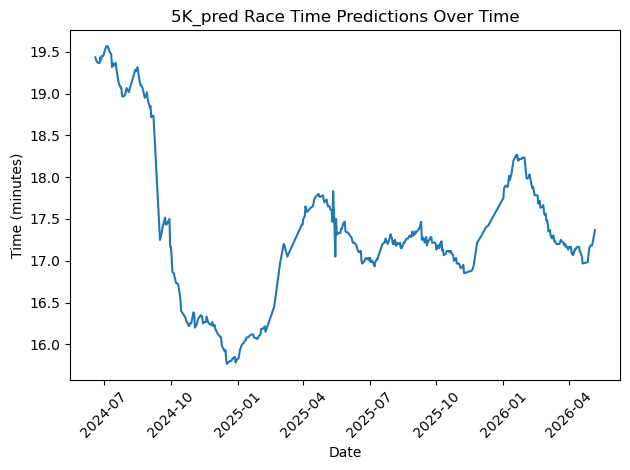

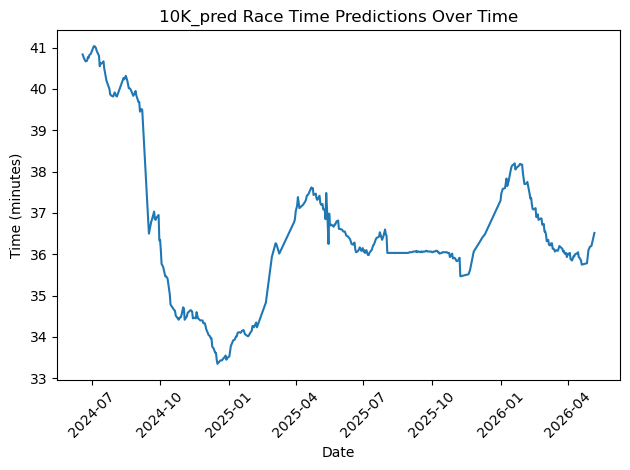

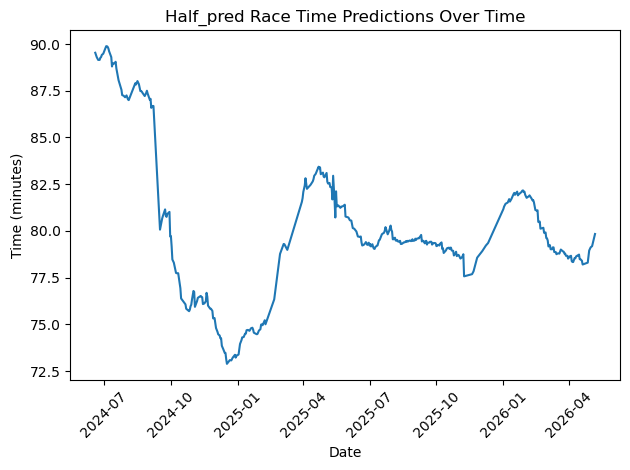

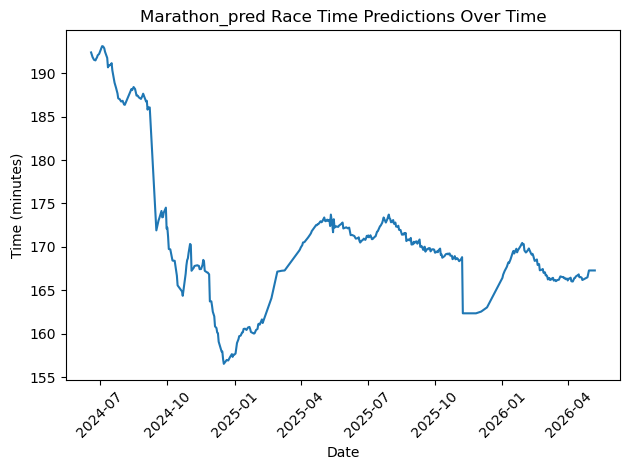

In [7]:
# Plot garmin race predictions over time
for prediction in predictions_type: 
    plt.figure
    sns.lineplot(data=daily_master_table, x='date', y=prediction)
    plt.title(f'{prediction} Race Time Predictions Over Time')
    plt.xlabel('Date')
    plt.ylabel('Time (minutes)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

First noteworth observation that can be seen in the data has to do with the a very fast decline in race predictions in 2024. Then the prediction times become incredily fast, which didn't accurately reflect my physical capability back then. I believe this may be due to me getting new Garmin hardware which introduced race prediction technology.

In [8]:
events_table = pd.read_csv('/Users/pabloherreramendez/Desktop/health_performance_project/data_raw/events_table.csv')
events_table['date'] = pd.to_datetime(events_table['date'])
print(events_table.info())
print(events_table)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               16 non-null     datetime64[ns]
 1   event_type         16 non-null     object        
 2   label              16 non-null     object        
 3   official_time_min  11 non-null     float64       
 4   race_type          11 non-null     object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 772.0+ bytes
None
         date            event_type                     label  \
0  2026-04-20                  race           Boston Marathon   
1  2026-01-07  training_block_start              Boston Build   
2  2025-11-09                  rest                      Rest   
3  2025-11-08                  race    Indiannapolis Marathon   
4  2025-08-04  training_block_start       Indiannapolis Build   
5  2025-08-02                  race       

/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_2703/3207925791.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  events_table['date'] = pd.to_datetime(events_table['date'])


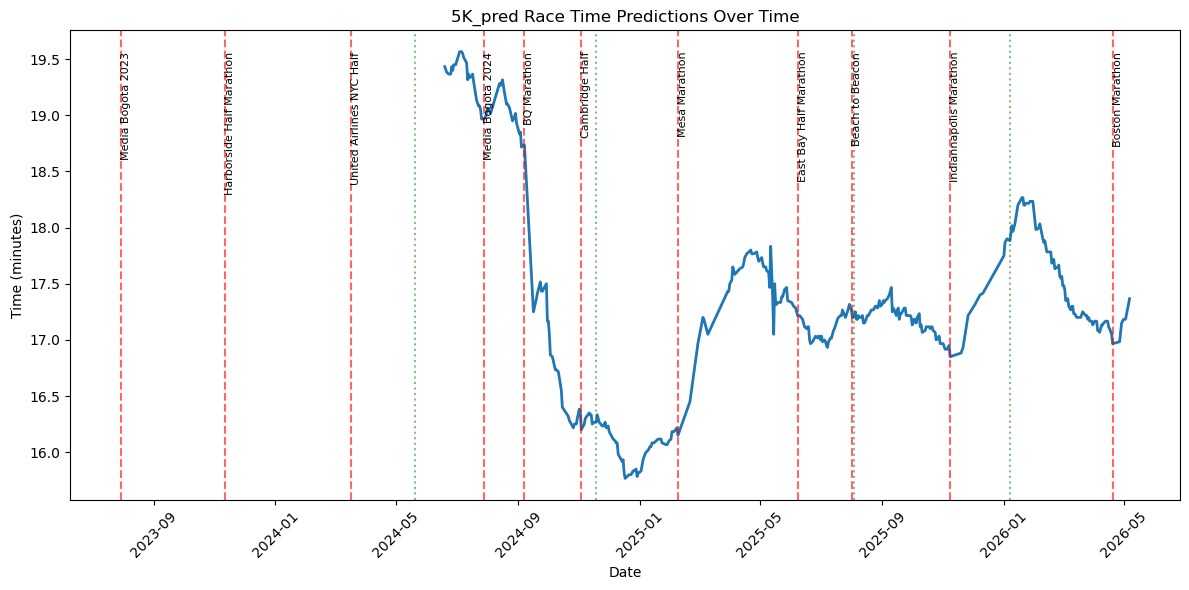

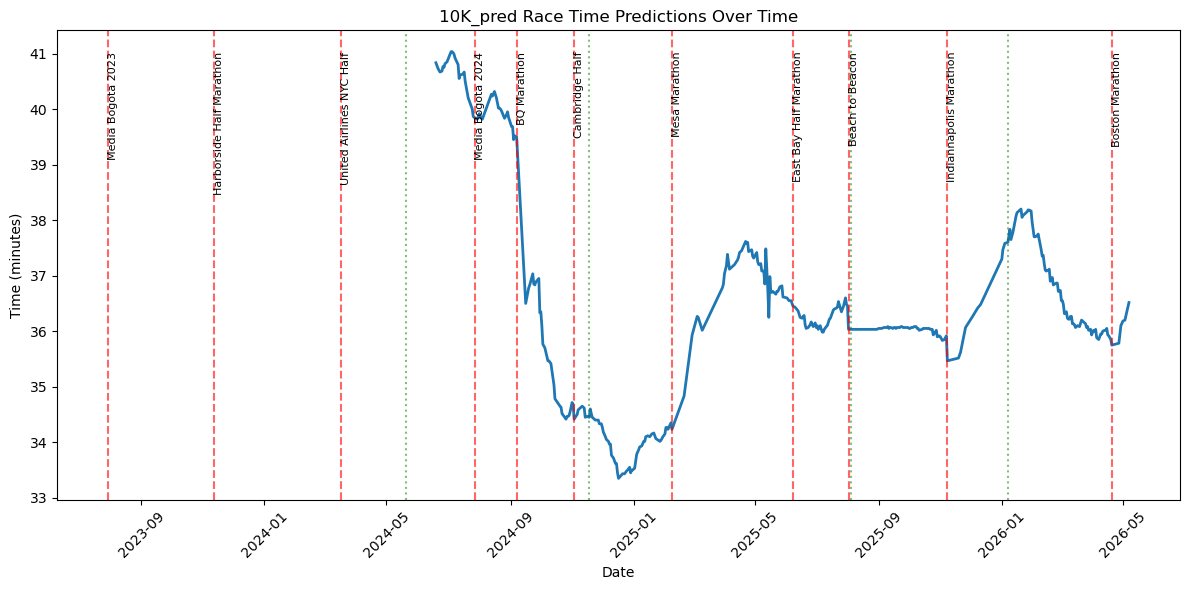

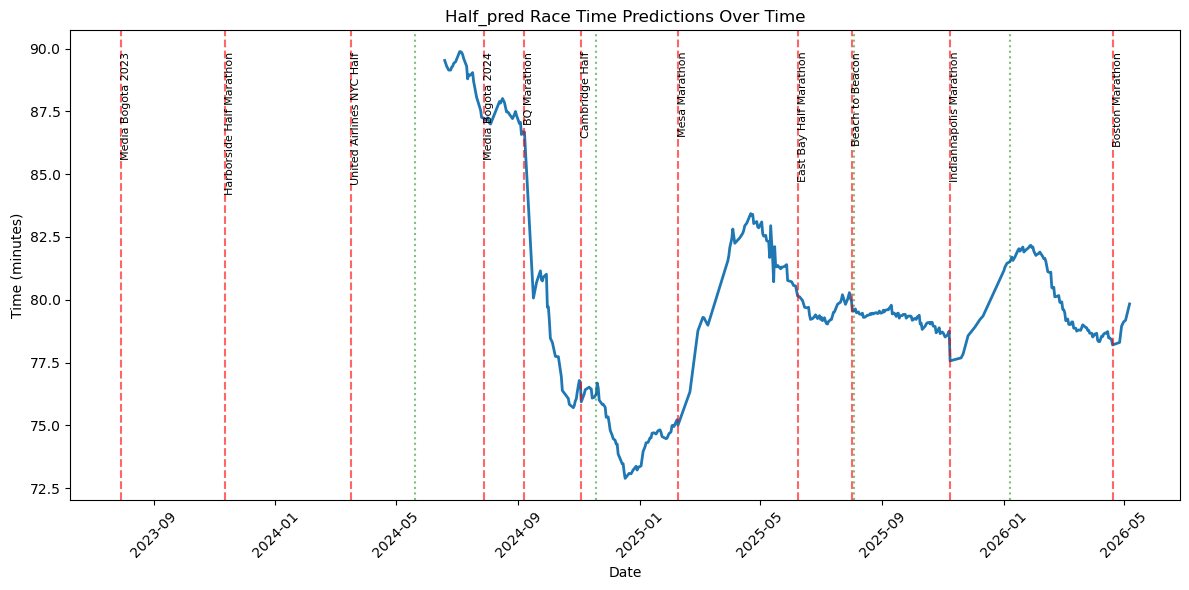

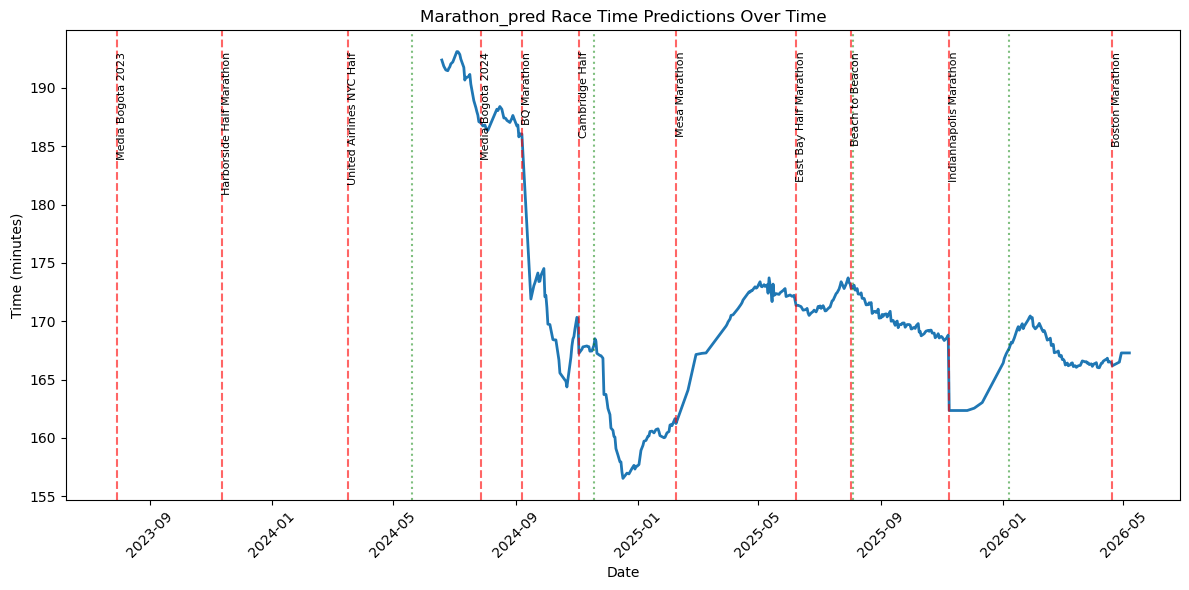

In [9]:
# Select races
race_events = events_table[
    events_table["event_type"] == "race"
]

# Select training block starts
block_events = events_table[
    events_table["event_type"] == "training_block_start"
]

# Plot predictions with race and block start markers
for prediction in predictions_type:

    plt.figure(figsize=(12, 6))

    # Prediction curve
    sns.lineplot(
        data=daily_master_table,
        x='date',
        y=prediction,
        linewidth=2
    )

    # Race markers
    for _, row in race_events.iterrows():
        plt.axvline(
            row["date"],
            color='red',
            linestyle='--',
            alpha=0.6
        )

        plt.text(
            row["date"],
            daily_master_table[prediction].max(),
            row["label"],
            rotation=90,
            fontsize=8,
            verticalalignment='top'
        )

    # Training block starts
    for _, row in block_events.iterrows():
        plt.axvline(
            row["date"],
            color='green',
            linestyle=':',
            alpha=0.5
        )

    plt.title(f'{prediction} Race Time Predictions Over Time')
    plt.xlabel('Date')
    plt.ylabel('Time (minutes)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

PREDICTION LEAKAGE: Predictions for race days actually take into account the race ran, so to make a meaningful comparison we need to observe the predictions from the day before the race.

In [10]:
# Create a predictions and actual time data frame

# Prediction date = day before race
race_events["prediction_date"] = race_events["date"] - pd.Timedelta(days=1)

# Select prediction columns
prediction_cols = [
    "date",
    "5K_pred",
    "10K_pred",
    "Half_pred",
    "Marathon_pred"
]

daily_sorted = daily_master_table.sort_values("date")
race_sorted = race_events.sort_values("prediction_date")

race_prediction_eval_df = pd.merge_asof(
    race_sorted,
    daily_sorted[prediction_cols],
    left_on="prediction_date",
    right_on="date",
    direction="backward"
)

race_prediction_eval_df = race_prediction_eval_df.rename(
    columns={"date_x": "race_date", "date_y": "prediction_date_matched"}
)

race_prediction_eval_df

/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_2703/1127184761.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  race_events["prediction_date"] = race_events["date"] - pd.Timedelta(days=1)


,race_date,event_type,label,official_time_min,race_type,prediction_date,prediction_date_matched,5K_pred,10K_pred,Half_pred,Marathon_pred
0,2023-07-30,race,Media Bogota 2023,119.6300,half,2023-07-29,2023-07-23,NaN,NaN,NaN,NaN
1,2023-11-12,race,Harborside Half Marathon,87.2500,half,2023-11-11,2023-11-11,NaN,NaN,NaN,NaN
2,2024-03-17,race,United Airlines NYC Half,81.6800,half,2024-03-16,2024-03-16,NaN,NaN,NaN,NaN
3,2024-07-28,race,Media Bogota 2024,87.4670,half,2024-07-27,2024-07-26,18.966667,39.866667,87.266667,187.100000
4,2024-09-07,race,BQ Marathon,180.9330,marathon,2024-09-06,2024-09-05,18.733333,39.516667,86.683333,186.050000
5,2024-11-03,race,Cambridge Half,80.3000,half,2024-11-02,2024-11-02,16.366667,34.683333,76.733333,170.233333
6,2025-02-08,race,Mesa Marathon,169.2833,marathon,2025-02-07,2025-02-07,16.216667,34.350000,75.216667,161.650000
7,2025-06-08,race,East Bay Half Marathon,82.3500,half,2025-06-07,2025-06-06,17.283333,36.550000,80.550000,172.216667
8,2025-08-02,race,Beach to Beacon,36.5670,10k,2025-08-01,2025-08-01,17.266667,36.450000,79.966667,173.200000
9,2025-11-08,race,Indiannapolis Marathon,164.4800,marathon,2025-11-07,2025-11-07,16.950000,35.916667,78.750000,168.816667


In [11]:
# Prediction mapping
prediction_map = {
    "5k": "5K_pred",
    "10k": "10K_pred",
    "half": "Half_pred",
    "marathon": "Marathon_pred"
}

def get_relevant_prediction(row):
    pred_col = prediction_map.get(row["race_type"])
    
    if pred_col:
        return row[pred_col]
    
    return None

race_prediction_eval_df["relevant_prediction"] = (
    race_prediction_eval_df.apply(
        get_relevant_prediction,
        axis=1
    )
)

In [12]:
race_prediction_eval_df["prediction_error"] = (
    race_prediction_eval_df["relevant_prediction"]
    - race_prediction_eval_df["official_time_min"]
)

In [13]:
race_prediction_eval_df.groupby("race_type")[
    "prediction_error"
].agg(["mean", "std", "count"])

,mean,std,count
race_type,,,
10k,-0.117000,NaN,1
half,-1.855667,1.683857,3
marathon,-0.573992,6.295077,4


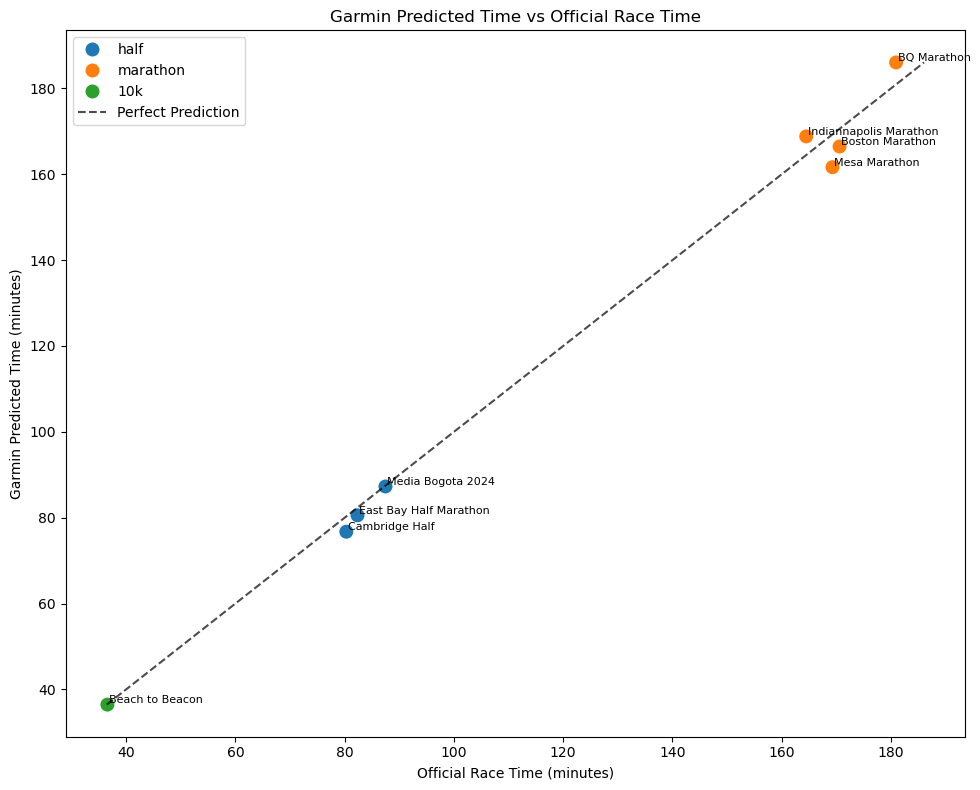

In [14]:
# Plot official time vs predicted time
plt.figure(figsize=(10, 8))

# Scatter plot
sns.scatterplot(
    data=race_prediction_eval_df,
    x="official_time_min",
    y="relevant_prediction",
    hue="race_type",
    s=120
)

# Perfect prediction reference line
min_val = min(
    race_prediction_eval_df["official_time_min"].min(),
    race_prediction_eval_df["relevant_prediction"].min()
)

max_val = max(
    race_prediction_eval_df["official_time_min"].max(),
    race_prediction_eval_df["relevant_prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="black",
    alpha=0.7,
    label="Perfect Prediction"
)

# Annotate race names
for _, row in race_prediction_eval_df.iterrows():

    if pd.notna(row["relevant_prediction"]):

        plt.text(
            row["official_time_min"] + 0.3,
            row["relevant_prediction"] + 0.3,
            row["label"],
            fontsize=8
        )

plt.title("Garmin Predicted Time vs Official Race Time")
plt.xlabel("Official Race Time (minutes)")
plt.ylabel("Garmin Predicted Time (minutes)")
plt.legend()
plt.tight_layout()
plt.show()

TODOS:
- error by race type
- optimism/conservatism analysis
- volatility analysis
- prediction evolution during marathon blocks

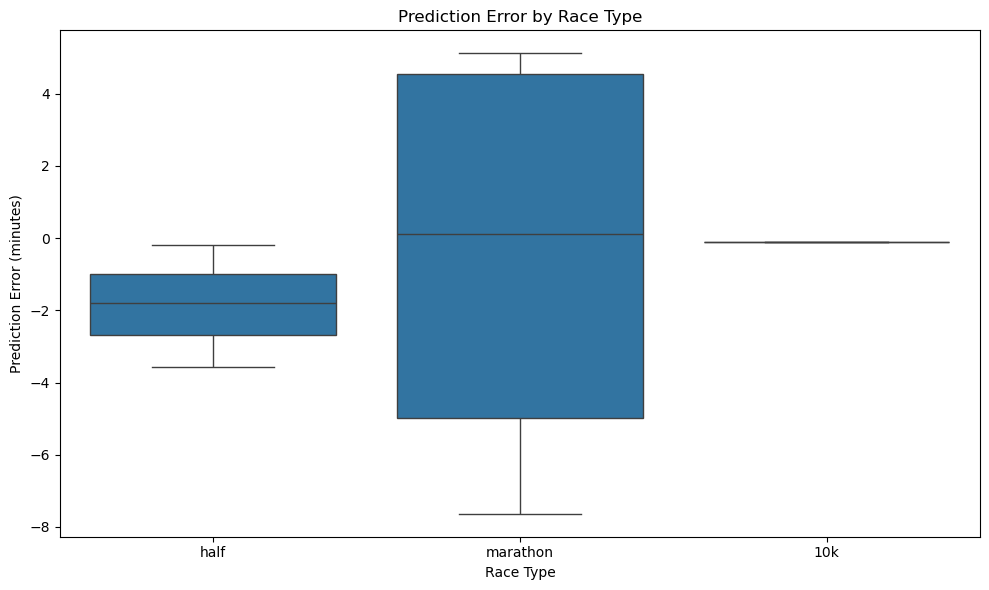

In [15]:
# Compute error by race type and plot boxplot of prediction error
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=race_prediction_eval_df, x="race_type", y="prediction_error")
plt.title("Prediction Error by Race Type")
plt.xlabel("Race Type")
plt.ylabel("Prediction Error (minutes)")
plt.tight_layout()
plt.show()

In [16]:
# optimism/conservatism analysis
race_prediction_eval_df["error_category"] = race_prediction_eval_df["prediction_error"].apply(
    lambda x: "optimistic" if x < 0 else ("conservative" if x > 0 else "neutral"))

print(race_prediction_eval_df)
print(race_prediction_eval_df["error_category"].value_counts())

    race_date event_type                     label  official_time_min  \
0  2023-07-30       race         Media Bogota 2023           119.6300   
1  2023-11-12       race  Harborside Half Marathon            87.2500   
2  2024-03-17       race  United Airlines NYC Half            81.6800   
3  2024-07-28       race         Media Bogota 2024            87.4670   
4  2024-09-07       race               BQ Marathon           180.9330   
5  2024-11-03       race            Cambridge Half            80.3000   
6  2025-02-08       race             Mesa Marathon           169.2833   
7  2025-06-08       race    East Bay Half Marathon            82.3500   
8  2025-08-02       race           Beach to Beacon            36.5670   
9  2025-11-08       race    Indiannapolis Marathon           164.4800   
10 2026-04-20       race           Boston Marathon           170.5830   

   race_type prediction_date prediction_date_matched    5K_pred   10K_pred  \
0       half      2023-07-29              202

My Garmin watch tends to be more optimistic than conservative in gerneral. Furthermore, I have observed that as the distance of the race prediction increases, the prediction error also increases. This suggests that the watch has a harder time predicting times for races such as a marathon and half marathon compared to a 10k. I also want to note that I have not raced many 10ks or 5ks so I want to somehow also analyze harder efforts in training sessions such as tempos and thresholds or unofficial time-trials done outside an organized race.

In [17]:
# Volatility analysis: compute rolling std of predictions in the 7, 15, and 30 days leading up to each race
time_windows = [7, 15, 30]


for time in time_windows:
    daily_master_table[f"rolling_std_{time}_5Kd"] = (
        daily_master_table["5K_pred"].rolling(window=time).std()
    )

    daily_master_table[f"rolling_std_{time}_10Kd"] = (
        daily_master_table["10K_pred"].rolling(window=time).std()
    )

    daily_master_table[f"rolling_std_{time}_Halfd"] = (
        daily_master_table["Half_pred"].rolling(window=time).std()
    )

    daily_master_table[f"rolling_std_{time}_Marathond"] = (
        daily_master_table["Marathon_pred"].rolling(window=time).std()
    )

# print(daily_master_table.filter(like="rolling_std").sample(10))

# A lot of these dates are NaN because of the rolling window, but we can still merge these features into the race_prediction_eval_df for analysis
rolling_cols = [col for col in daily_master_table.columns if "rolling_std" in col]
daily_sorted = daily_master_table.sort_values("date")
race_prediction_eval_df = pd.merge_asof(
    race_prediction_eval_df,
    daily_sorted[["date"] + rolling_cols],
    left_on="prediction_date_matched",
    right_on="date",
    direction="backward"
)
# Run in next cell to avoid merge issues


    race_date event_type                     label  official_time_min  \
0  2023-07-30       race         Media Bogota 2023           119.6300   
1  2023-11-12       race  Harborside Half Marathon            87.2500   
2  2024-03-17       race  United Airlines NYC Half            81.6800   
3  2024-07-28       race         Media Bogota 2024            87.4670   
4  2024-09-07       race               BQ Marathon           180.9330   
5  2024-11-03       race            Cambridge Half            80.3000   
6  2025-02-08       race             Mesa Marathon           169.2833   
7  2025-06-08       race    East Bay Half Marathon            82.3500   
8  2025-08-02       race           Beach to Beacon            36.5670   
9  2025-11-08       race    Indiannapolis Marathon           164.4800   
10 2026-04-20       race           Boston Marathon           170.5830   

   race_type prediction_date prediction_date_matched    5K_pred   10K_pred  \
0       half      2023-07-29              202

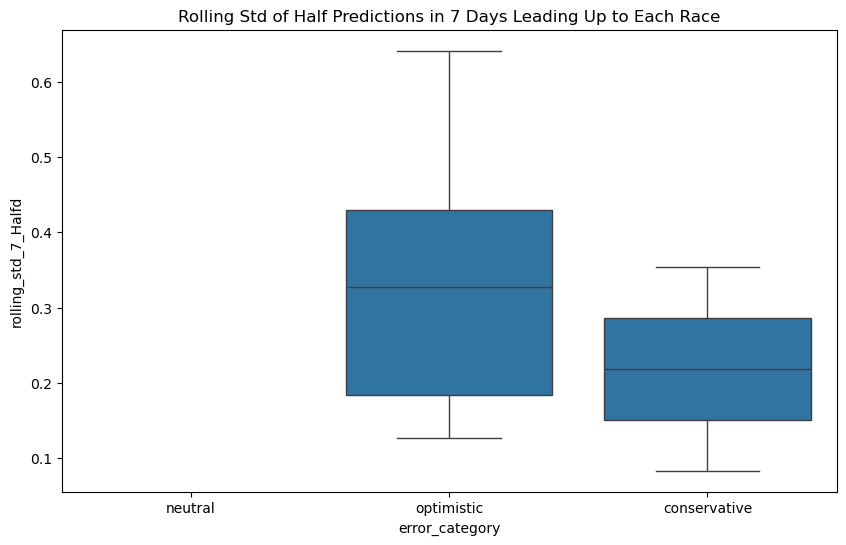

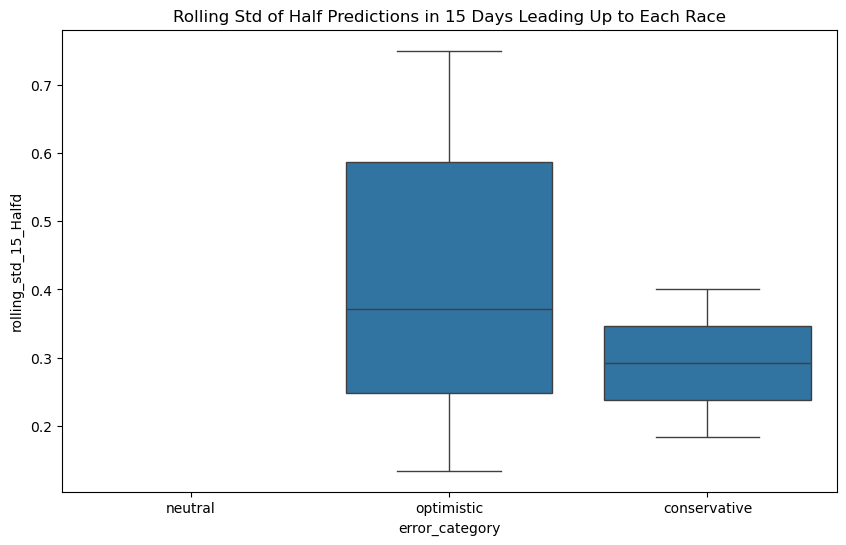

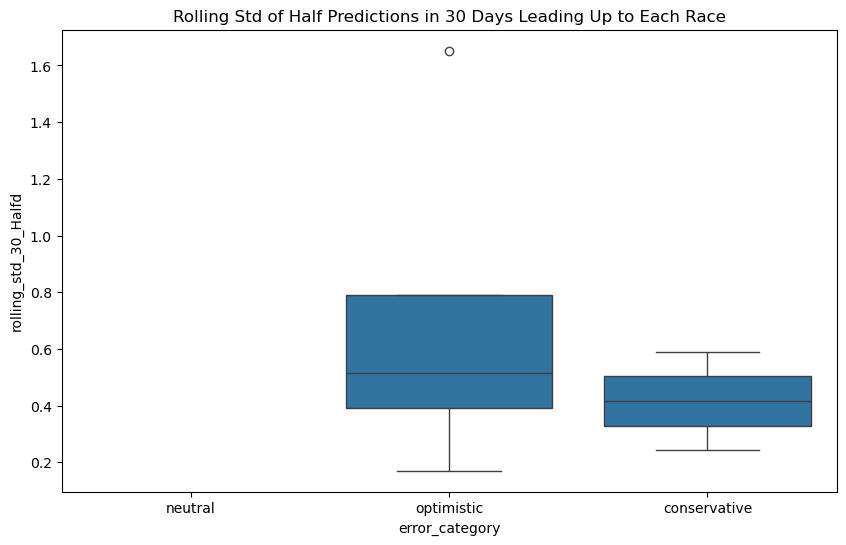

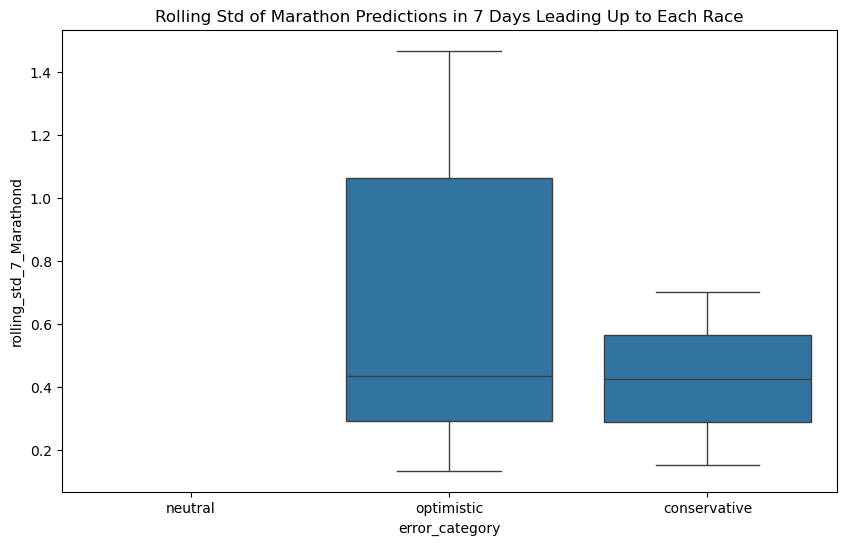

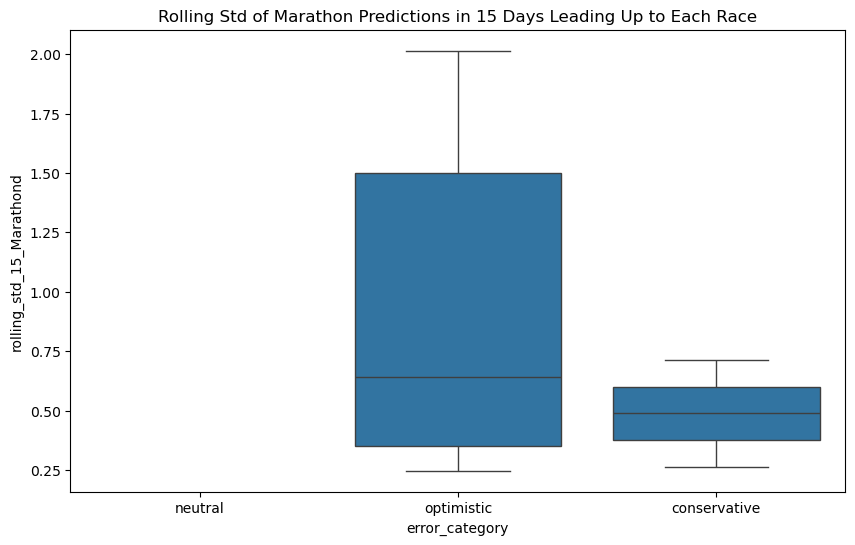

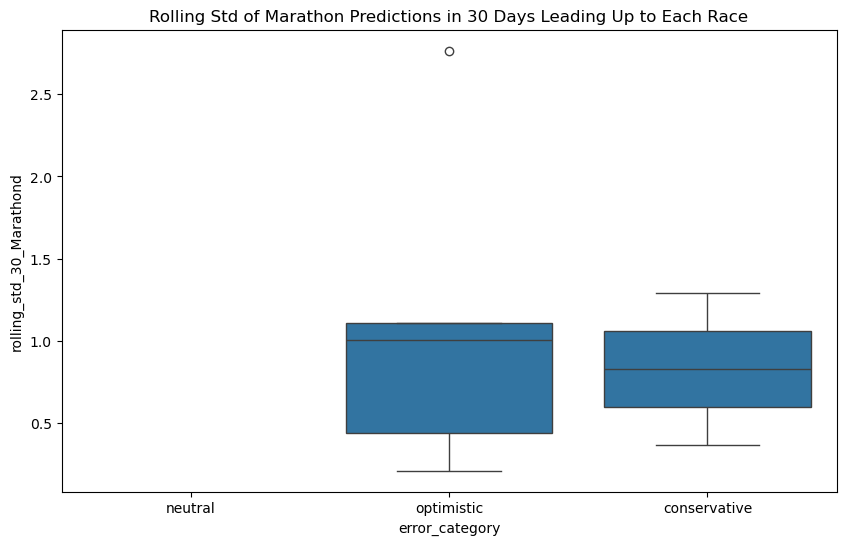

In [18]:
print(race_prediction_eval_df)
# Volatility analysis: compare rolling std of predictions leading up to each race between optimistic and conservative predictions
# Looking at marathon and half predictions since 5k and 10k predictions have a lot of missing values in the rolling std features
for time in time_windows:
    plt.figure(figsize=(10,6))
    sns.boxplot(
        data=race_prediction_eval_df,
        x="error_category",
        y="rolling_std_{}_Halfd".format(time)
    )
    plt.title(f"Rolling Std of Half Predictions in {time} Days Leading Up to Each Race")
    plt.show()

for time in time_windows:
    plt.figure(figsize=(10,6))
    sns.boxplot(
        data=race_prediction_eval_df,
        x="error_category",
        y="rolling_std_{}_Marathond".format(time)
    )
    plt.title(f"Rolling Std of Marathon Predictions in {time} Days Leading Up to Each Race")
    plt.show()

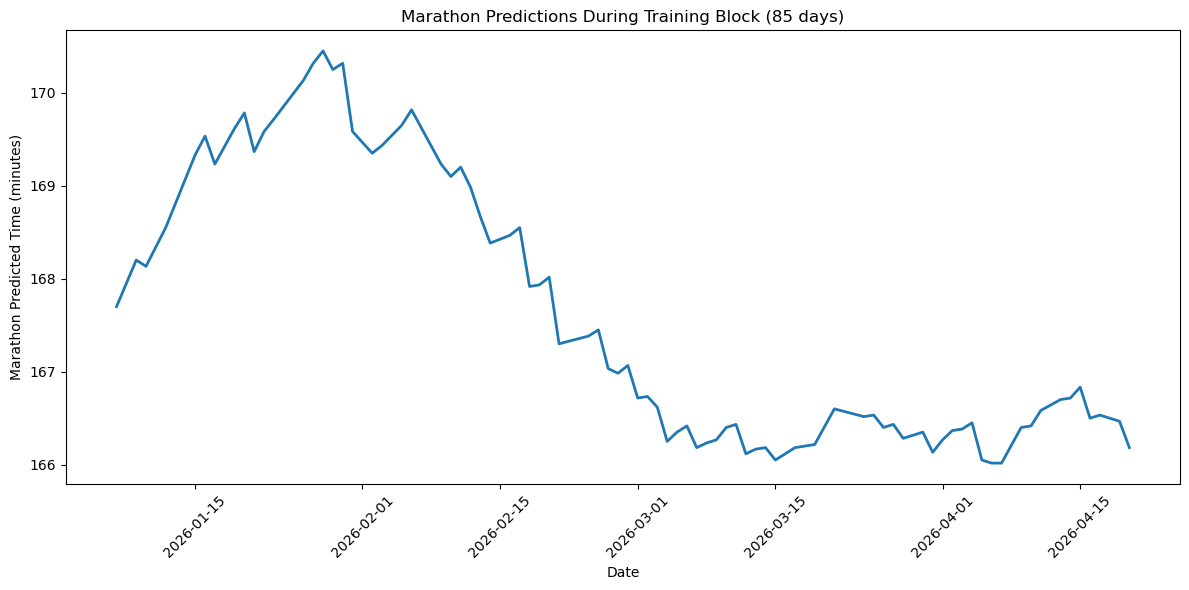

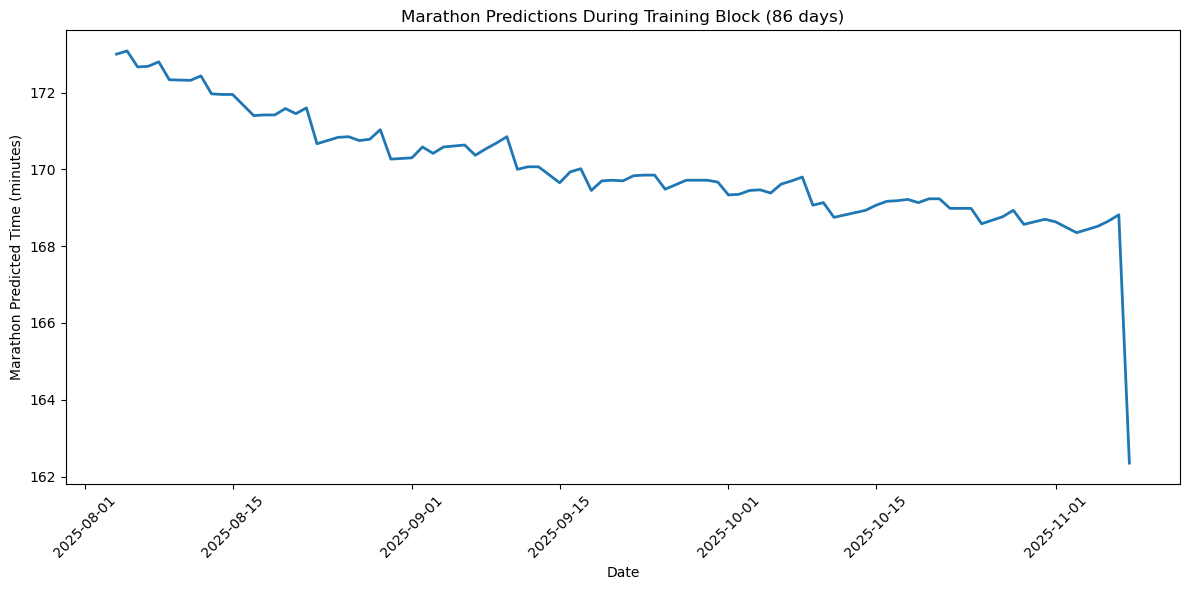

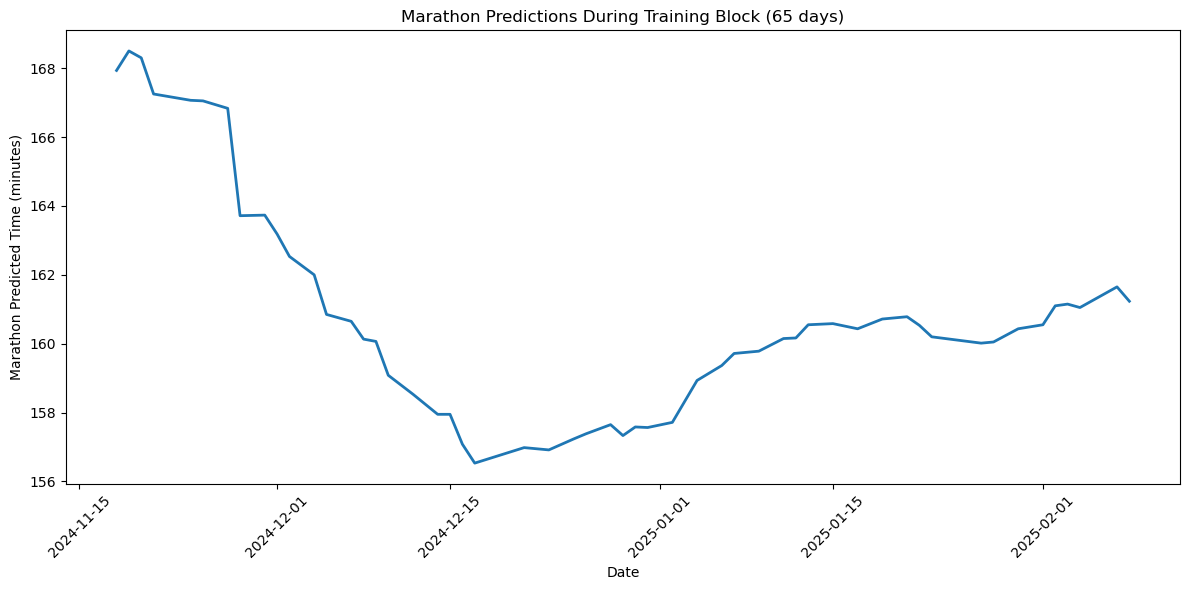

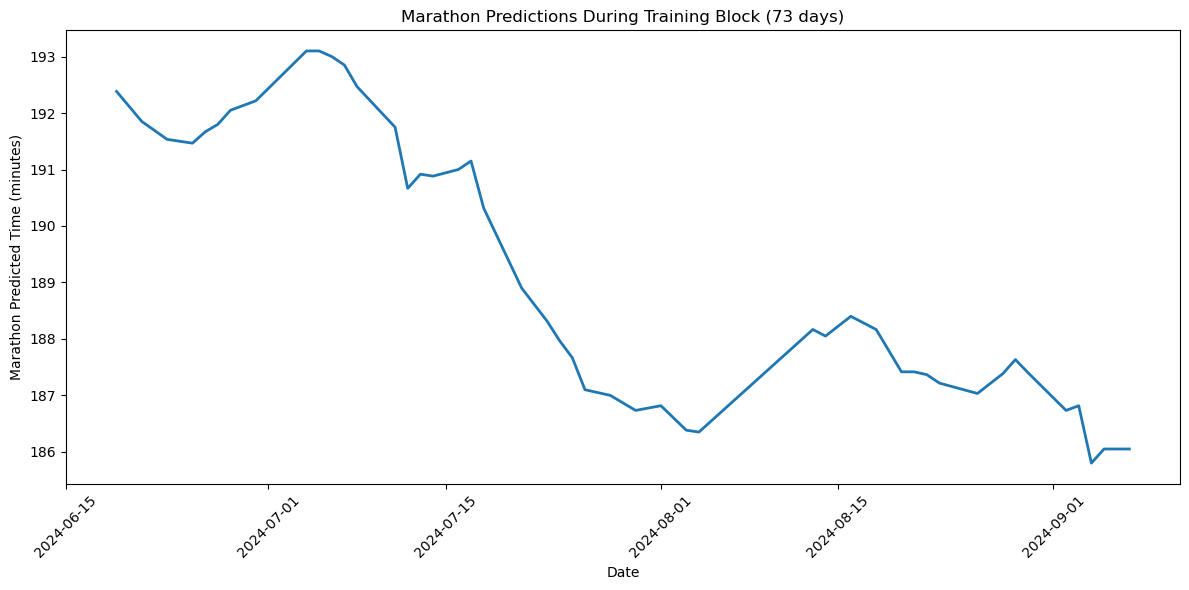

In [19]:
# There exist 4 marathon blocks in the events table
# Create a new dataframe for each marathon block using the dates in the table, manually select the dates
boston_block_daily = daily_master_table[
    (daily_master_table["date"] >= pd.to_datetime("2026-01-07")) &
    (daily_master_table["date"] <= pd.to_datetime("2026-04-20"))
]


indianapolis_block_daily = daily_master_table[
    (daily_master_table["date"] >= pd.to_datetime("8/4/25")) &
    (daily_master_table["date"] <= pd.to_datetime("11/8/25"))
]

mesa_block_daily = daily_master_table[
    (daily_master_table["date"] >= pd.to_datetime("11/18/24")) &
    (daily_master_table["date"] <= pd.to_datetime("2/8/25"))
]

bq_block_daily = daily_master_table[
    (daily_master_table["date"] >= pd.to_datetime("5/20/24")) &
    (daily_master_table["date"] <= pd.to_datetime("9/7/24"))
]

marathon_blocks = [boston_block_daily, indianapolis_block_daily, mesa_block_daily, bq_block_daily]

for block in marathon_blocks:
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=block,
        x='date',
        y='Marathon_pred',
        linewidth=2
    )
    plt.title(f'Marathon Predictions During Training Block ({block.shape[0]} days)')
    plt.xlabel('Date')
    plt.ylabel('Marathon Predicted Time (minutes)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [20]:
# Add information from the race_prediction_eval_df into the marathon block dataframes for further analysis
boston_block_daily = pd.merge_asof(
    boston_block_daily.sort_values("date"),
    race_prediction_eval_df.sort_values("date"),
    on="date",
    direction="backward"
)
indianapolis_block_daily = pd.merge_asof(
    indianapolis_block_daily.sort_values("date"),
    race_prediction_eval_df.sort_values("date"),
    on="date",
    direction="backward"
)
mesa_block_daily = pd.merge_asof(
    mesa_block_daily.sort_values("date"),
    race_prediction_eval_df.sort_values("date"),
    on="date",
    direction="backward"
)
bq_block_daily = pd.merge_asof(
    bq_block_daily.sort_values("date"),
    race_prediction_eval_df.sort_values("date"),
    on="date",
    direction="backward"
)




In [21]:
columns_to_drop = [
    "5K_pred_y",
    "10K_pred_y",
    "Half_pred_y",
    "Marathon_pred_y",
    "rolling_std_7_5Kd_y",
    "rolling_std_15_5Kd_y",
    "rolling_std_30_5Kd_y",
    "rolling_std_7_10Kd_y",
    "rolling_std_15_10Kd_y",
    "rolling_std_30_10Kd_y",
    "rolling_std_7_Halfd_y",
    "rolling_std_15_Halfd_y",
    "rolling_std_30_Halfd_y",
    "rolling_std_7_Marathond_y",
    "rolling_std_15_Marathond_y",
    "rolling_std_30_Marathond_y",
    "5K_pred_x",
    "10K_pred_x",
    "Half_pred_x",
    "rolling_std_7_5Kd_x",
    "rolling_std_15_5Kd_x",
    "rolling_std_30_5Kd_x",
    "rolling_std_7_10Kd_x",
    "rolling_std_15_10Kd_x",
    "rolling_std_30_10Kd_x",
    "rolling_std_7_Halfd_x",
    "rolling_std_15_Halfd_x",
    "rolling_std_30_Halfd_x",
]

boston_block_daily = boston_block_daily.drop(columns=columns_to_drop)
indianapolis_block_daily = indianapolis_block_daily.drop(columns=columns_to_drop)
mesa_block_daily = mesa_block_daily.drop(columns=columns_to_drop)  
bq_block_daily = bq_block_daily.drop(columns=columns_to_drop)

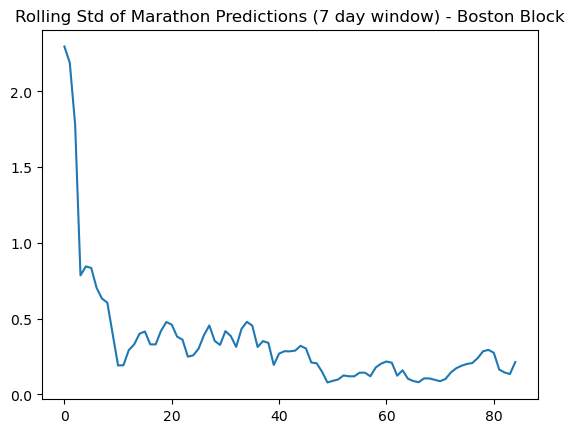

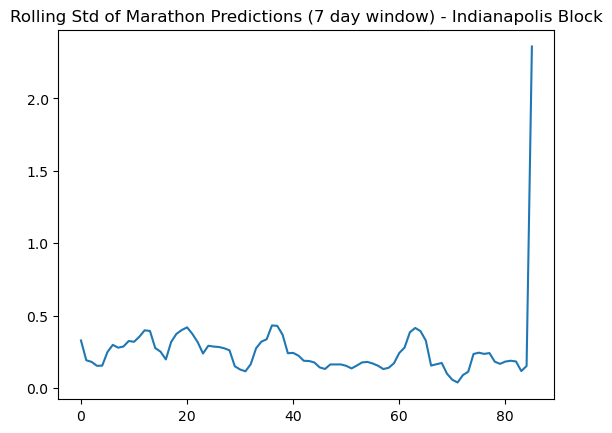

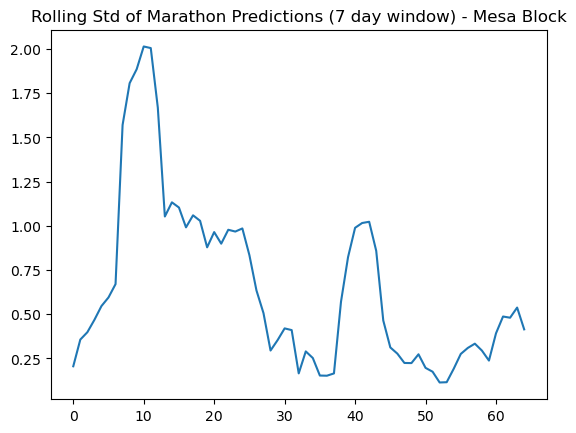

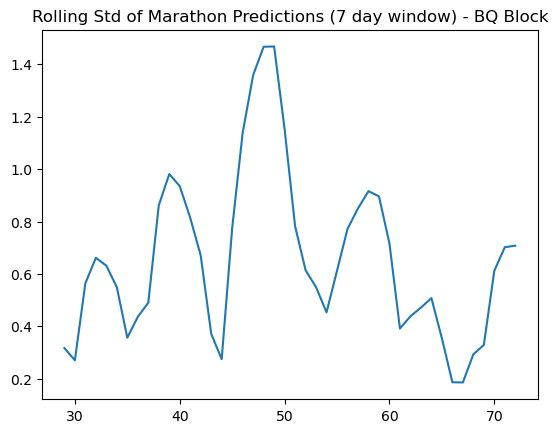

In [22]:
# Determine when predictions start to become more stable (less volatile) using the rolling std features in the marathon blocks
boston_block_daily["rolling_std_7_Marathond_x"].plot(title="Rolling Std of Marathon Predictions (7 day window) - Boston Block")
plt.show()

indianapolis_block_daily["rolling_std_7_Marathond_x"].plot(title="Rolling Std of Marathon Predictions (7 day window) - Indianapolis Block")
plt.show()

mesa_block_daily["rolling_std_7_Marathond_x"].plot(title="Rolling Std of Marathon Predictions (7 day window) - Mesa Block")
plt.show()

bq_block_daily["rolling_std_7_Marathond_x"].plot(title="Rolling Std of Marathon Predictions (7 day window) - BQ Block")
plt.show()

### Rolling Prediction Volatility Across Marathon Blocks

The rolling standard deviation plots reveal that Garmin marathon prediction behavior varies substantially across different training blocks. Rather than following a single consistent pattern, each block appears to exhibit its own distinct prediction dynamics.

Several observations stand out immediately:

- The Indianapolis Marathon block appears relatively stable throughout most of the training cycle, with consistently low rolling volatility. Interestingly, this block also resulted in the strongest marathon performance in the dataset.
  
- The Mesa Marathon block shows significantly higher volatility, including multiple abrupt spikes and large fluctuations in predicted marathon fitness. This same block also produced Garmin’s largest optimistic prediction error relative to the official race result.

- The Boston Marathon block demonstrates an initial adaptation period followed by a long phase of remarkably low volatility, suggesting that Garmin’s prediction system may have converged on a stable estimate of fitness late in the cycle.

- The BQ Marathon block displays repeated oscillatory behavior, with several cycles of increasing and decreasing volatility. This may indicate that Garmin repeatedly reevaluated fitness status throughout the build.

These results suggest that the *dynamics* of Garmin race predictions may be just as important as the final predicted value itself. In particular, prediction stability and volatility may provide insight into:
- training consistency,
- physiological adaptation,
- model confidence,
- or uncertainty in estimated marathon fitness.

At this stage, no definitive conclusions are being made. However, the differences between marathon blocks suggest that prediction volatility may be a meaningful signal worth investigating further.

In [23]:
print(boston_block_daily.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 59 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            85 non-null     datetime64[ns]
 1   run_count                       85 non-null     int64         
 2   total_distance_km               85 non-null     float64       
 3   total_distance_miles            85 non-null     float64       
 4   total_duration_minutes          85 non-null     float64       
 5   total_moving_minutes            85 non-null     float64       
 6   total_elevation_gain_m          85 non-null     float64       
 7   avg_hr                          85 non-null     float64       
 8   max_hr                          85 non-null     float64       
 9   avg_pace_mile                   85 non-null     float64       
 10  avg_power                       85 non-null     float64       
 11  max_powe

In [24]:
boston_block_daily.to_parquet(
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/boston_block_daily_v1.parquet',
    index=False
)

indianapolis_block_daily.to_parquet(
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/indianapolis_block_daily_v1.parquet',
    index=False
)

mesa_block_daily.to_parquet(
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/mesa_block_daily_v1.parquet',
    index=False
)

bq_block_daily.to_parquet(
    '/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/bq_block_daily_v1.parquet',
    index=False
)

In [25]:
# === Scratch paper ===

